In [179]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn import linear_model
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import MaxAbsScaler
from sklearn.preprocessing import RobustScaler
from sklearn.preprocessing import PowerTransformer
from sklearn.preprocessing import QuantileTransformer

from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from sklearn.impute import KNNImputer


In [91]:
reg = linear_model.LinearRegression()
reg.fit([[0, 0], [1, 1], [2, 2]], [0, 1, 2])
reg.coef_

array([0.5, 0.5])

In [92]:
data = sns.load_dataset('titanic')
data.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [93]:
missing_val = round(data.isnull().sum()/len(data)*100, 2).sort_values(ascending=False)
# len(data)
missing_val


deck           77.22
age            19.87
embarked        0.22
embark_town     0.22
survived        0.00
pclass          0.00
sex             0.00
sibsp           0.00
parch           0.00
fare            0.00
class           0.00
who             0.00
adult_male      0.00
alive           0.00
alone           0.00
dtype: float64

<Axes: >

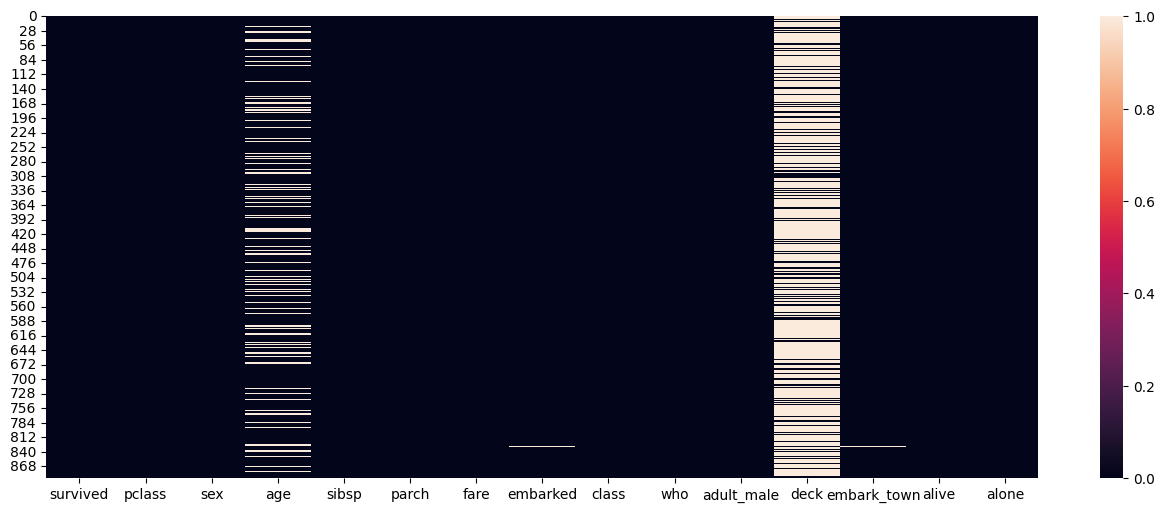

In [94]:
plt.figure(figsize=(16,6))
sns.heatmap(data.isnull())

In [95]:
data['age'] = data['age'].fillna(data['age'].mean())
data['embarked'] = data['embarked'].fillna(data['embarked'].mode()[0])
data['embark_town'] = data['embark_town'].fillna(data['embark_town'].mode()[0])

In [96]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    str     
 3   age          891 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     891 non-null    str     
 8   class        891 non-null    category
 9   who          891 non-null    str     
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  891 non-null    str     
 13  alive        891 non-null    str     
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), str(5)
memory usage: 80.7 KB


In [97]:
df = sns.load_dataset('titanic')
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    str     
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    str     
 8   class        891 non-null    category
 9   who          891 non-null    str     
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    str     
 13  alive        891 non-null    str     
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), str(5)
memory usage: 80.7 KB


In [98]:
df['age'].mean()

np.float64(29.69911764705882)

In [99]:
df['age'].median()

np.float64(28.0)

In [100]:
df['age'].mode()

0    24.0
Name: age, dtype: float64

In [101]:
df.isnull().sum().sort_values(ascending=False)

deck           688
age            177
embarked         2
embark_town      2
survived         0
pclass           0
sex              0
sibsp            0
parch            0
fare             0
class            0
who              0
adult_male       0
alive            0
alone            0
dtype: int64

In [102]:
# Imopute age col using SimpleImputer from sklearn

imputer = SimpleImputer(strategy="mean")
df['age'] = imputer.fit_transform(df[['age']])

In [103]:
# Imopute age col using IterativeImputer from sklearn

imputer = IterativeImputer(max_iter=20, n_nearest_features= 5)
df['age'] = imputer.fit_transform(df[['age']])

In [104]:
# Imopute age col using Forward & Backward fill from sklearn

# df['age'] = df['age'].ffill()
# df['age'] = df['age'].bfill()

In [105]:
# Imopute age col using KNNImputer from sklearn

imputer = KNNImputer(n_neighbors=5)
df['age'] = imputer.fit_transform(df[['age']])

In [106]:
mean1 = np.mean(df['age'])
std = np.std(df['age'])

In [107]:
# Now Using Z-Score remove Outliers

df['z-score'] = (df['age'] - mean1) /std
df

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone,z-score
0,0,3,male,22.000000,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False,-0.592481
1,1,1,female,38.000000,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False,0.638789
2,1,3,female,26.000000,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True,-0.284663
3,1,1,female,35.000000,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False,0.407926
4,0,3,male,35.000000,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True,0.407926
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,0,2,male,27.000000,0,0,13.0000,S,Second,man,True,NaN,Southampton,no,True,-0.207709
887,1,1,female,19.000000,0,0,30.0000,S,First,woman,False,B,Southampton,yes,True,-0.823344
888,0,3,female,29.699118,1,2,23.4500,S,Third,woman,False,NaN,Southampton,no,False,0.000000
889,1,1,male,26.000000,0,0,30.0000,C,First,man,True,C,Cherbourg,yes,True,-0.284663


In [108]:
# Removing Outliers based on Z-score > 3
df[df['z-score'] > 3]
df = df[df['z-score'] < 3]
df.info()


<class 'pandas.DataFrame'>
Index: 884 entries, 0 to 890
Data columns (total 16 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     884 non-null    int64   
 1   pclass       884 non-null    int64   
 2   sex          884 non-null    str     
 3   age          884 non-null    float64 
 4   sibsp        884 non-null    int64   
 5   parch        884 non-null    int64   
 6   fare         884 non-null    float64 
 7   embarked     882 non-null    str     
 8   class        884 non-null    category
 9   who          884 non-null    str     
 10  adult_male   884 non-null    bool    
 11  deck         200 non-null    category
 12  embark_town  882 non-null    str     
 13  alive        884 non-null    str     
 14  alone        884 non-null    bool    
 15  z-score      884 non-null    float64 
dtypes: bool(2), category(2), float64(3), int64(4), str(5)
memory usage: 93.7 KB


In [109]:
# Sample data
temp_data = [2.5,2.9,3,4.1,4.4,5.5,6.7,19]

In [110]:
# Calculate the Z-Score for each data point
z_score = np.abs(stats.zscore(temp_data))

# Set a threshold for indentifying outliers
threshold = 2.5
outliers = set(np.where(z_score > threshold)[0])

print('--------------------------------------')
print(temp_data)
print('--------------------------------------')

print('Indices of Outliers', outliers)
print('--------------------------------------')
print('Outliers', [temp_data[i] for i in outliers])
print('--------------------------------------')

# Remove Outliers
temp_data = [temp_data[i] for i in range(len(temp_data)) if i not in outliers]
print(f'Data without Outliers: {temp_data}')


--------------------------------------
[2.5, 2.9, 3, 4.1, 4.4, 5.5, 6.7, 19]
--------------------------------------
Indices of Outliers {np.int64(7)}
--------------------------------------
Outliers [19]
--------------------------------------
Data without Outliers: [2.5, 2.9, 3, 4.1, 4.4, 5.5, 6.7]


In [111]:
print(z_score)

[0.69090586 0.61222619 0.59255627 0.37618718 0.31717742 0.10080833
 0.13523068 2.55463056]


`Dealing with Outliers`

Z-Score \
IQR \
K-Mean

In [112]:
# Calculate the Z-Score for each data point
z_score = np.abs(stats.zscore(temp_data))

# Set a threshold for indentifying outliers
threshold = 2.5
outliers = set(np.where(z_score > threshold)[0])

print('--------------------------------------')
print(temp_data)
print('--------------------------------------')

print('Indices of Outliers', outliers)
print('--------------------------------------')
print('Outliers', [temp_data[i] for i in outliers])
print('--------------------------------------')

# Remove Outliers
temp_data = [temp_data[i] for i in range(len(temp_data)) if i not in outliers]
print(f'Data without Outliers: {temp_data}')


--------------------------------------
[2.5, 2.9, 3, 4.1, 4.4, 5.5, 6.7]
--------------------------------------
Indices of Outliers set()
--------------------------------------
Outliers []
--------------------------------------
Data without Outliers: [2.5, 2.9, 3, 4.1, 4.4, 5.5, 6.7]


`Merge Data`

In [113]:
# Sample Datasets for merging

data1 = {
    'id' : [1,2,3],
    'name' : ['Ahmed', 'Fatima', 'Ali'],
    'age' : [28,32,24]
}

df1 = pd.DataFrame(data1)

data2 = {
    'id' : [1,2,3],
    'city' : ['Karachi', 'Lahore', 'Islamabad'],
    'work' : ['IT',"AM","PM"]
}

df2 = pd.DataFrame(data2)

merged = pd.merge(df1, df2, how='inner', on='id')
merged

,id,name,age,city,work
0,1,Ahmed,28,Karachi,IT
1,2,Fatima,32,Lahore,AM
2,3,Ali,24,Islamabad,PM


In [114]:
# Standard Scalar
# Sample data for Scaling

data3 = {
    'age' : [28,32,24],
    'height' : [165, 140, 185],
    'weight' : [60, 45, 80]
}

df3 = pd.DataFrame(data3)
df3

#import the scalar
scalar = StandardScaler()

#fit the scalar
scaled_df = scalar.fit_transform(df3)
scaled_df

array([[ 0.        ,  0.09053575, -0.11624764],
       [ 1.22474487, -1.26750044, -1.16247639],
       [-1.22474487,  1.1769647 ,  1.27872403]])

In [115]:
df3

,age,height,weight
0,28,165,60
1,32,140,45
2,24,185,80


In [116]:
scaled_df = pd.DataFrame(scaled_df, columns=df3.columns)
scaled_df

,age,height,weight
0,0.000000,0.090536,-0.116248
1,1.224745,-1.267500,-1.162476
2,-1.224745,1.176965,1.278724


In [117]:
# Min-Max Scalar
# Sample data for Scaling

data3 = {
    'age' : [28,32,24],
    'height' : [165, 140, 185],
    'weight' : [60, 45, 80]
}

df4 = pd.DataFrame(data3)
df4

#import the scalar
scalar = MinMaxScaler()

#fit the scalar
scaled_df = scalar.fit_transform(df4)
scaled_df

array([[0.5       , 0.55555556, 0.42857143],
       [1.        , 0.        , 0.        ],
       [0.        , 1.        , 1.        ]])

In [118]:
scaled_df = pd.DataFrame(scaled_df, columns=df4.columns)
scaled_df

,age,height,weight
0,0.5,0.555556,0.428571
1,1.0,0.000000,0.000000
2,0.0,1.000000,1.000000


In [119]:
# MaxAbs Scalar
# Sample data for Scaling

data3 = {
    'age' : [28,32,24],
    'height' : [165, 140, 185],
    'weight' : [60, 45, 80]
}

df5 = pd.DataFrame(data3)
df5

#import the scalar
scalar = MaxAbsScaler()

#fit the scalar
scaled_df = scalar.fit_transform(df5)
scaled_df

array([[0.875     , 0.89189189, 0.75      ],
       [1.        , 0.75675676, 0.5625    ],
       [0.75      , 1.        , 1.        ]])

In [120]:
scaled_df = pd.DataFrame(scaled_df, columns=df5.columns)
scaled_df

,age,height,weight
0,0.875,0.891892,0.7500
1,1.000,0.756757,0.5625
2,0.750,1.000000,1.0000


In [121]:
# Robust Scalar
# Sample data for Scaling

data3 = {
    'age' : [28,32,24],
    'height' : [165, 140, 185],
    'weight' : [60, 45, 80]
}

df6 = pd.DataFrame(data3)
df6

#import the scalar
scalar = RobustScaler()

#fit the scalar
scaled_df = scalar.fit_transform(df6)
scaled_df

array([[ 0.        ,  0.        ,  0.        ],
       [ 1.        , -1.11111111, -0.85714286],
       [-1.        ,  0.88888889,  1.14285714]])

In [122]:
scaled_df = pd.DataFrame(scaled_df, columns=df6.columns)
scaled_df

,age,height,weight
0,0.0,0.000000,0.000000
1,1.0,-1.111111,-0.857143
2,-1.0,0.888889,1.142857


In [123]:
# Generate non normal data (exponential distirbution)

np.random.seed(0)
df =np.random.exponential(size=1000, scale=2)
df = pd.DataFrame(df, columns=['values'])
df.head()


,values
0,1.591749
1,2.511862
2,1.846446
3,1.574402
4,1.102097


<Axes: xlabel='values', ylabel='Count'>

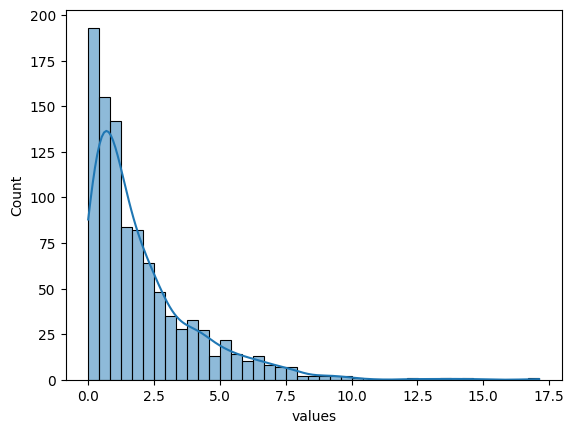

In [124]:
# Ploting 

sns.histplot(df['values'], kde=True)

<Axes: ylabel='Count'>

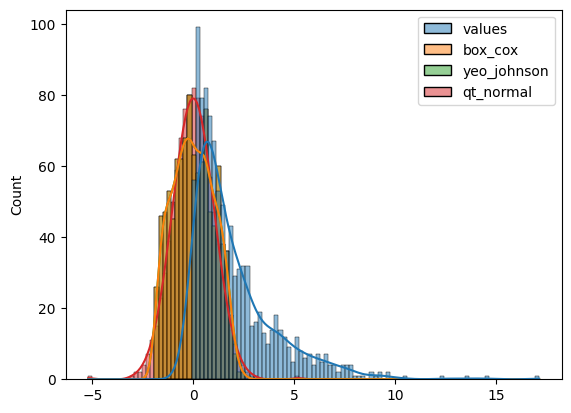

In [181]:
# Transforming

pt_boxcox = PowerTransformer(method='box-cox')  #data should be postive for boxcox
pt_yeo_johnson = PowerTransformer(method='yeo-johnson')
qt_normal = QuantileTransformer(output_distribution='normal')

df['box_cox'] = pt_boxcox.fit_transform(df[['values']]+1)
df['yeo_johnson'] = pt_yeo_johnson.fit_transform(df[['values']])
df['qt_normal'] = qt_normal.fit_transform(df[['values']])
df.head()

sns.histplot(df, kde=True)


In [183]:
df.head()

,values,box_cox,yeo_johnson,qt_normal
0,1.591749,0.179335,0.179335,0.162552
1,2.511862,0.677330,0.677331,0.587964
2,1.846446,0.339698,0.339698,0.286135
3,1.574402,0.167607,0.167607,0.157469
4,1.102097,-0.202107,-0.202107,-0.154930


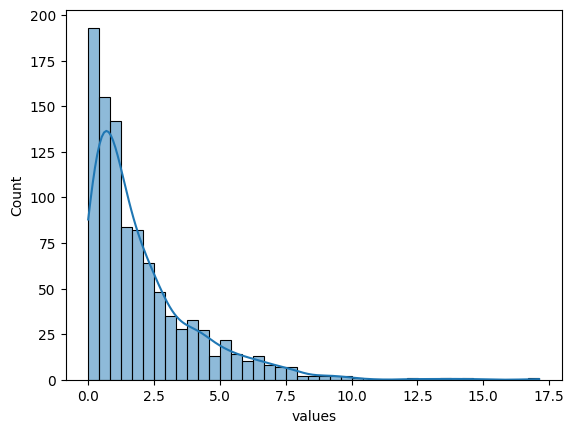

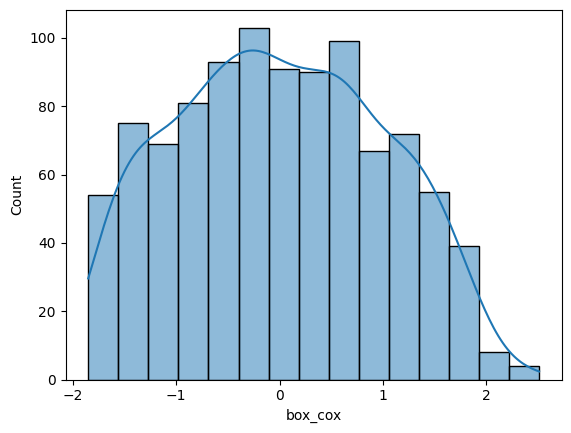

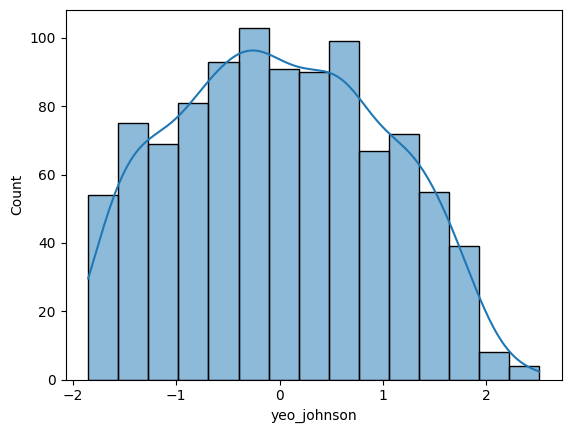

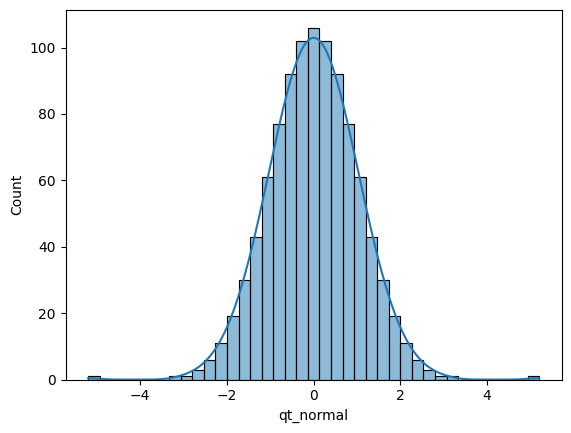

In [ ]:
# plots for each

for col in df.columns:
    # plt.Figure()
    sns.histplot(df[col], kde=True)
    plt.show()
    
